# Threshold Analysis: SA vs SlotODE Unsupervised Segmentation

Compare argmax slot masks under a confidence threshold $\tau$ for three matched-$T$ models:

- **SA**, $T = 5$ — sourced from Modal (`run_modal_threshold.py`, run remotely due to local GPU/JAX issue)
- **SlotODE**, $T = 5$, $\Delta t = 1$ — local inference
- **SlotODE**, $T = 5$, $\Delta t = 0.5$ — local inference

Pixels with max slot probability $< \tau$ are excluded from the IoU computation. We sweep $\tau$, plot mIoU vs $\tau$ overlaid for the three models, and produce a qualitative figure (input | GT | argmax of each model | thresholded of each model).

**Pipeline.** Each model entry below has a `source`:
- `local`: load checkpoint, run inference + sweep here.
- `modal_npz`: load a precomputed `.npz` produced by `run_modal_threshold.py` (download with `modal volume get slotode-ckpts <run_name>/threshold_data.npz ./<dest>.npz`).

When at least one run is `modal_npz`, its `images` + `gt_segs` are used as the canonical set, and any `local` runs are evaluated on the same images so per-image arrays line up for the qualitative figure.

In [10]:
import pickle
from pathlib import Path

import jax
jax.config.update("jax_default_matmul_precision", "highest")
import jax.numpy as jnp
import equinox as eqx
import numpy as np
from PIL import Image
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

from model import SlotODEModel
from model_baseline import SlotAttentionModel

import seaborn as sns
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

## 1. Configure runs

In [11]:
RUNS = {
    "SA T=5": {
        "source": "modal_npz",
        "npz": "runs_data/threshold_data_baseline_sa_s11_T5.npz",
    },
    "SlotODE T=5 dt=1": {
        "source": "local",
        "ckpt": "runs_data/omkos-slotode/slot_ode_11_slots_euler_T5_dt1/checkpoints/best.eqx",
        "kind": "ode",
    },
    "SlotODE T=5 dt=0.5": {
        "source": "local",
        "ckpt": "runs_data/omkos-slotode/slot_ode_11_slots_euler_T5_dt0.5/checkpoints/best.eqx",
        "kind": "ode",
    },
}

DATA_DIR = Path("CLEVR_64")
N_EVAL = 5000
RESOLUTION = (64, 64)
NUM_SLOTS = 11
THRESHOLDS = np.arange(0.0, 0.96, 0.025)

## 2. Load canonical val data

If any run is `modal_npz`, that npz's `images` + `gt_segs` are canonical. Otherwise load locally.

In [12]:
def load_val_data_local(data_dir, n, resolution):
    img_dir = data_dir / "images" / "val"
    mask_dir = data_dir / "masks" / "val"
    vis_dir = data_dir / "visibility" / "val"
    images, gt_segs = [], []
    for ip in sorted(img_dir.glob("*.png"))[:n]:
        stem = ip.stem
        mp = mask_dir / f"{stem}.npy"
        vp = vis_dir / f"{stem}.npy"
        if not mp.exists():
            continue
        img = np.array(Image.open(ip).convert("RGB"), dtype=np.float32) / 127.5 - 1.0
        img = np.transpose(img, (2, 0, 1))
        images.append(img)
        masks = np.load(mp)
        visibility = np.load(vp) if vp.exists() else np.ones(11, dtype=np.float32)
        seg = np.zeros((resolution[0], resolution[1]), dtype=np.int32)
        for obj_idx in range(1, 11):
            if visibility[obj_idx] > 0.5:
                seg[masks[obj_idx] > 127] = obj_idx
        gt_segs.append(seg)
    return np.stack(images), np.stack(gt_segs)

modal_runs = [(n, c) for n, c in RUNS.items() if c["source"] == "modal_npz"]
if modal_runs:
    name0, cfg0 = modal_runs[0]
    z = np.load(cfg0["npz"], allow_pickle=False)
    images_np = z["images"]
    gt_segs = z["gt_segs"]
    print(f"canonical data from {name0}: {len(gt_segs)} images, masks shape {z['masks'].shape}")
else:
    images_np, gt_segs = load_val_data_local(DATA_DIR, N_EVAL, RESOLUTION)
    print(f"canonical data from local: {len(gt_segs)} images")

canonical data from SA T=5: 5000 images, masks shape (5000, 11, 64, 64)


## 3. Gather masks per run

For `modal_npz`: load masks + sweep curve from npz. For `local`: load checkpoint, run inference.

In [13]:
def load_local_model(cfg, key):
    meta_path = cfg["ckpt"].replace(".eqx", "_meta.pkl")
    with open(meta_path, "rb") as f:
        meta = pickle.load(f)
    args = meta["args"]
    if cfg["kind"] == "sa":
        model = SlotAttentionModel(
            resolution=RESOLUTION, num_slots=args["num_slots"], slot_dim=args["slot_dim"],
            enc_hidden_dim=args.get("enc_hidden_dim", 64), num_iter=args["num_iter"], key=key,
        )
    else:
        model = SlotODEModel(
            resolution=RESOLUTION, num_slots=args["num_slots"], slot_dim=args["slot_dim"],
            enc_hidden_dim=args.get("enc_hidden_dim", 64), num_iter=args["num_iter"],
            dt0=args.get("dt", None) or 1.0, key=key,
        )
    model = eqx.tree_deserialise_leaves(cfg["ckpt"], model)
    return model, meta

@eqx.filter_jit
def predict(model, images, key):
    recon, masks, slots = model(images, key=key)
    return masks

def run_inference(model, images_np, batch_size=32, seed=42):
    key = jax.random.key(seed)
    out = []
    for i in range(0, len(images_np), batch_size):
        batch = jnp.array(images_np[i:i + batch_size])
        key, sk = jax.random.split(key)
        out.append(np.array(predict(model, batch, sk)))
    return np.concatenate(out, axis=0)

results = {}
for name, cfg in RUNS.items():
    if cfg["source"] == "modal_npz":
        z = np.load(cfg["npz"], allow_pickle=False)
        results[name] = {
            "masks": z["masks"],
            "thresholds": z["thresholds"],
            "miou_mean": z["miou_mean"],
            "miou_std": z["miou_std"],
            "best_tau": float(z["best_tau"]),
            "best_miou": float(z["best_miou"]),
            "baseline_miou": float(z["baseline_miou"]),
            "from_npz": True,
        }
        print(f"{name}: loaded from npz, masks {z['masks'].shape}")
    else:
        print(f"{name}: running local inference...")
        model, _ = load_local_model(cfg, jax.random.key(0))
        masks = run_inference(model, images_np)
        results[name] = {"masks": masks, "from_npz": False}
        print(f"  masks {masks.shape}")
        del model

SA T=5: loaded from npz, masks (5000, 11, 64, 64)
SlotODE T=5 dt=1: running local inference...
  masks (5000, 11, 64, 64)
SlotODE T=5 dt=0.5: running local inference...
  masks (5000, 11, 64, 64)


## 4. Threshold sweep for local runs (npz runs already have curves)

In [14]:
def compute_miou_thresholded(pred_probs, gt_mask, num_pred_slots, tau):
    pred_mask = pred_probs.argmax(axis=0)
    max_prob = pred_probs.max(axis=0)
    confident = max_prob >= tau
    gt_ids = np.unique(gt_mask)
    gt_ids = gt_ids[gt_ids > 0]
    n_gt = len(gt_ids)
    if n_gt == 0:
        return 1.0
    iou = np.zeros((n_gt, num_pred_slots))
    for i, gid in enumerate(gt_ids):
        gb = (gt_mask == gid)
        for j in range(num_pred_slots):
            pb = (pred_mask == j) & confident
            inter = (gb & pb).sum()
            union = (gb | pb).sum()
            iou[i, j] = inter / max(union, 1)
    ri, ci = linear_sum_assignment(-iou)
    return iou[ri, ci].mean()

def sweep(masks_arr, gt_segs, num_slots, thresholds):
    means, stds = [], []
    for tau in thresholds:
        scores = [compute_miou_thresholded(masks_arr[k], gt_segs[k], num_slots, tau)
                  for k in range(len(gt_segs))]
        means.append(np.mean(scores))
        stds.append(np.std(scores))
    return np.array(means), np.array(stds)

for name in RUNS:
    if results[name]["from_npz"]:
        continue
    print(f"sweeping {name}...")
    m, s = sweep(results[name]["masks"], gt_segs, NUM_SLOTS, THRESHOLDS)
    best = int(m.argmax())
    results[name].update({
        "thresholds": THRESHOLDS,
        "miou_mean": m,
        "miou_std": s,
        "best_tau": float(THRESHOLDS[best]),
        "best_miou": float(m[best]),
        "baseline_miou": float(m[0]),
    })
    print(f"  baseline (tau=0): {m[0]:.4f}    best: {m[best]:.4f} at tau={THRESHOLDS[best]:.3f}")

sweeping SlotODE T=5 dt=1...
  baseline (tau=0): 0.1874    best: 0.8614 at tau=0.550
sweeping SlotODE T=5 dt=0.5...
  baseline (tau=0): 0.1641    best: 0.8550 at tau=0.575


In [15]:
print(f"{'Model':25s} {'mIoU(tau=0)':>12s} {'best mIoU':>11s} {'tau*':>8s}")
print("-" * 60)
for name in RUNS:
    r = results[name]
    print(f"{name:25s} {r['baseline_miou']:>12.4f} {r['best_miou']:>11.4f} {r['best_tau']:>8.3f}")

Model                      mIoU(tau=0)   best mIoU     tau*
------------------------------------------------------------
SA T=5                          0.1984      0.8014    0.625
SlotODE T=5 dt=1                0.1874      0.8614    0.550
SlotODE T=5 dt=0.5              0.1641      0.8550    0.575


## 5. mIoU vs $\tau$ overlay

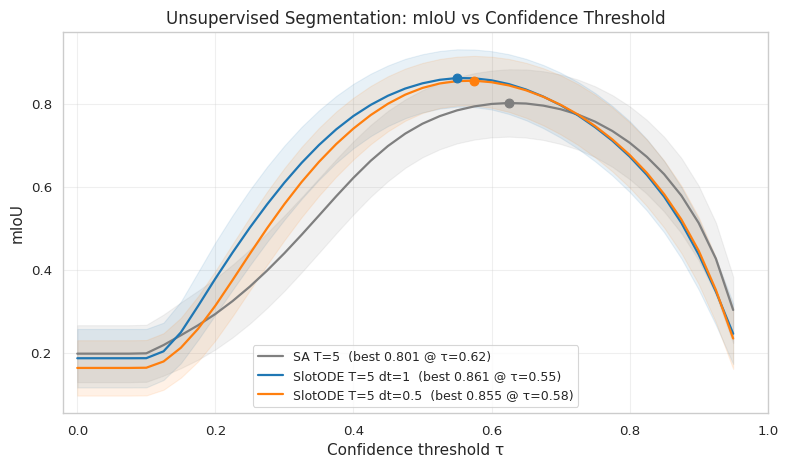

In [16]:
COLORS = {
    "SA T=5": "tab:gray",
    "SlotODE T=5 dt=1": "tab:blue",
    "SlotODE T=5 dt=0.5": "tab:orange",
}

fig, ax = plt.subplots(figsize=(8, 4.8))
for name in RUNS:
    r = results[name]
    c = COLORS.get(name, None)
    ax.plot(r["thresholds"], r["miou_mean"], "-", color=c, linewidth=1.6,
            label=f"{name}  (best {r['best_miou']:.3f} @ \u03c4={r['best_tau']:.2f})")
    ax.fill_between(r["thresholds"],
                    r["miou_mean"] - r["miou_std"],
                    r["miou_mean"] + r["miou_std"],
                    color=c, alpha=0.10)
    ax.scatter([r["best_tau"]], [r["best_miou"]], color=c, s=40, zorder=5)

ax.set_xlabel("Confidence threshold \u03c4", fontsize=11)
ax.set_ylabel("mIoU", fontsize=11)
ax.set_title("Unsupervised Segmentation: mIoU vs Confidence Threshold", fontsize=12)
ax.legend(fontsize=9, loc="lower center")
ax.set_xlim(-0.02, 1.0)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("thesis_draft/figures/miou_threshold.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Qualitative comparison

Per scene: input | GT segmentation | argmax of each model | thresholded (at each model's $\tau^\star$) of each model. Excluded pixels in dark gray.

chosen scenes: 3 objects -> idx 42, 5 objects -> idx 132, 8 objects -> idx 20


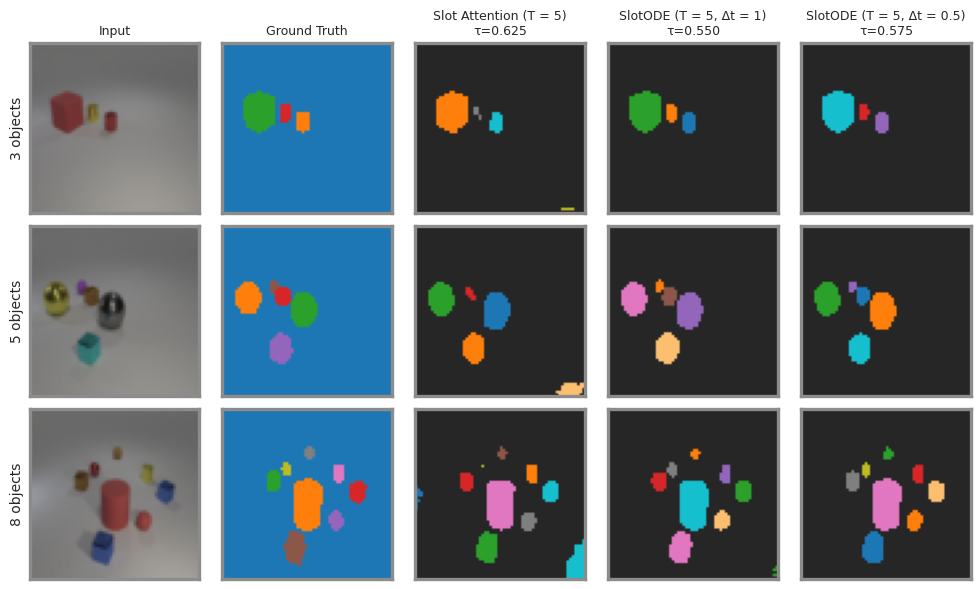

In [17]:
SLOT_COLORS = np.array([
    [0.12, 0.47, 0.71], [1.0, 0.50, 0.05], [0.17, 0.63, 0.17],
    [0.84, 0.15, 0.16], [0.58, 0.40, 0.74], [0.55, 0.34, 0.29],
    [0.89, 0.47, 0.76], [0.50, 0.50, 0.50], [0.74, 0.74, 0.13],
    [0.09, 0.75, 0.81], [0.99, 0.75, 0.44],
])
BG = (0.15, 0.15, 0.15)
PANEL_BORDER_COLOR = "0.55"     # neutral gray, matches qualitative_figure inactive style
PANEL_BORDER_LW = 2.4

def style_panel(ax, color=PANEL_BORDER_COLOR, linewidth=PANEL_BORDER_LW):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(linewidth)
    ax.set_xticks([]); ax.set_yticks([])

def to_img(x):
    return np.clip((x.transpose(1, 2, 0) + 1) / 2, 0, 1)

def seg_to_rgb(seg, bg=BG):
    H, W = seg.shape
    rgb = np.full((H, W, 3), bg)
    for s in range(SLOT_COLORS.shape[0]):
        rgb[seg == s] = SLOT_COLORS[s]
    return rgb

def seg_to_rgb_threshold(pred_probs, tau, bg=BG):
    seg = pred_probs.argmax(axis=0)
    max_prob = pred_probs.max(axis=0)
    H, W = seg.shape
    rgb = np.full((H, W, 3), bg)
    for s in range(SLOT_COLORS.shape[0]):
        mask = (seg == s) & (max_prob >= tau)
        rgb[mask] = SLOT_COLORS[s]
    return rgb

# Pick three example scenes: 3 objects, 5 objects, and one of {7, 8, 9}.
n_objects = np.array([int(np.sum(np.unique(gt) > 0)) for gt in gt_segs])

def first_with_count(target):
    matches = np.where(n_objects == target)[0]
    return int(matches[0]) if len(matches) else None

def first_in_set(targets):
    for t in targets:
        idx = first_with_count(t)
        if idx is not None:
            return idx, t
    return None, None

idx_3 = 42
idx_5 = 132
idx_high, count_high = first_in_set([8, 9])

assert idx_3 is not None, "no 3-object scene found"
assert idx_5 is not None, "no 5-object scene found"
assert idx_high is not None, "no 7/8/9-object scene found"

example_idxs = [idx_3, idx_5, idx_high]
print(f"chosen scenes: 3 objects -> idx {idx_3}, 5 objects -> idx {idx_5}, {count_high} objects -> idx {idx_high}")

# Columns: input | GT | thresholded segmentation per model (one column each)
model_names = list(RUNS.keys())
n_cols = 2 + len(model_names)
n_rows = len(example_idxs)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.0 * n_cols, 2.0 * n_rows))

namelist = list(model_names)
col_titles = [
    "Input",
    "Ground Truth",
    f"Slot Attention (T = 5)\nτ={results[namelist[0]]['best_tau']:.3f}",
    f"SlotODE (T = 5, Δt = 1)\nτ={results[namelist[1]]['best_tau']:.3f}",
    f"SlotODE (T = 5, Δt = 0.5)\nτ={results[namelist[2]]['best_tau']:.3f}",
]

for r, idx in enumerate(example_idxs):
    axes[r, 0].imshow(to_img(images_np[idx]))
    axes[r, 1].imshow(seg_to_rgb(gt_segs[idx]))
    for mi, name in enumerate(model_names):
        masks_idx = results[name]["masks"][idx]
        tau_star = results[name]["best_tau"]
        axes[r, 2 + mi].imshow(seg_to_rgb_threshold(masks_idx, tau_star))
    for c in range(n_cols):
        style_panel(axes[r, c])
    axes[r, 0].set_ylabel(f"{int(n_objects[idx])} objects", fontsize=10)

for c, title in enumerate(col_titles):
    axes[0, c].set_title(title, fontsize=9)

fig.tight_layout()
fig.savefig("thesis_draft/figures/segmentation_examples.png", dpi=200, bbox_inches="tight")
plt.show()

In [18]:
np.where(n_objects == 8)[0][:15].tolist()

[20, 21, 35, 44, 47, 48, 53, 55, 56, 58, 64, 68, 75, 81, 97]